In [1]:
from IPython.display import clear_output
!pip install pip3-autoremove
!pip-autoremove torch torchvision torchaudio -y
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu121
!pip install unsloth
# Also get the latest nightly Unsloth!
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git
!pip install --upgrade --no-cache-dir transformers
clear_output()

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None  # Auto detection of dtype
load_in_4bit = True  # Reduce memory usage with 4-bit quantization

quantized_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-3B-Instruct",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.1.8: Fast Llama patching. Transformers: 4.48.2.
   \\   /|    GPU: Tesla P100-PCIE-16GB. Max memory: 15.888 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 6.0. CUDA Toolkit: 12.1. Triton: 3.1.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post1. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

In [4]:
#change name to lora model here
lora_layers_and_quantized_model = FastLanguageModel.get_peft_model(
    quantized_model,
    r=16,  # LoRA rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,  # Optimized at 0
    bias="none",  # No additional bias terms
    use_gradient_checkpointing="unsloth",  # Gradient checkpointing to save memory
    random_state=3407,
    use_rslora=False,  # Rank stabilized LoRA, can be enabled for stability
)


Unsloth 2025.1.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [5]:
!wget https://huggingface.co/datasets/miladmim/slim-orca-dedup-chat-50k-persian/resolve/main/data.jsonl?download=true

--2025-01-31 18:16:41--  https://huggingface.co/datasets/miladmim/slim-orca-dedup-chat-50k-persian/resolve/main/data.jsonl?download=true
Resolving huggingface.co (huggingface.co)... 3.165.160.11, 3.165.160.61, 3.165.160.12, ...
Connecting to huggingface.co (huggingface.co)|3.165.160.11|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/03/91/039119bf3b6f3c083e8207d297da2d654c372ba1b6778664345655e6e4af7aa5/3ca27a9b4e6f28661e2ac780ba648b1cf983c2e4508ceba00ab86dc3b2d465f3?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27data.jsonl%3B+filename%3D%22data.jsonl%22%3B&Expires=1738351001&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczODM1MTAwMX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzAzLzkxLzAzOTExOWJmM2I2ZjNjMDgzZTgyMDdkMjk3ZGEyZDY1NGMzNzJiYTFiNjc3ODY2NDM0NTY1NWU2ZTRhZjdhYTUvM2NhMjdhOWI0ZTZmMjg2NjFlMmFjNzgwYmE2NDhiMWNmOTgzYzJlNDUwOGNlYmEwMGFiODZkYzNi

In [11]:
import json
from datasets import Dataset

DS_PATH = "/kaggle/working/data.jsonl?download=true"

def read_dataset(ds_path):
    dataset = []
    with open(ds_path, 'r') as f:        
        for line in f:
            line = json.loads(line)
            filtered_conversations = [
                message for message in line 
                if message['role'] in ['user', 'assistant']
            ]
            conversation = {
                "conversations": filtered_conversations
            }
            dataset.append(conversation)            
    return dataset
         
dataset = read_dataset(ds_path=DS_PATH)
dataset = Dataset.from_list(dataset)


print("dataset: \n", dataset)
print("\n1st sample: \n", dataset[0])
print("\n2nd sample: \n", dataset[1])


dataset: 
 Dataset({
    features: ['conversations'],
    num_rows: 40458
})

1st sample: 
 {'conversations': [{'content': 'فاصله\u200cها را اضافه کنید: بازی\u200cهای تراکتور، تراکتور از مزرعه، تراکتور با تریلر', 'role': 'user'}, {'content': 'در اینجا عبارات جدا شده با فاصله\u200cهای اضافه شده آمده است:\n\n1. بازی\u200cهای تراکتور\n2. تراکتور از مزرعه\n3. تراکتور با تریلر\n\nحال اجازه دهید توضیح مفصلی درباره هر عبارت جدا شده ارائه دهم.\n\n1. بازی\u200cهای تراکتور: بازی\u200cهای تراکتور به دسته\u200cای از بازی\u200cهای ویدئویی یا آنلاین اشاره دارد که در آن\u200cها تراکتورها به عنوان بخش اصلی یا جدایی\u200cناپذیر بازی وجود دارند. این بازی\u200cها می\u200cتوانند اهداف و مقاصد مختلفی داشته باشند، از جمله مسابقه، شبیه\u200cسازی کشاورزی یا هدایت تراکتور. بازی\u200cهای تراکتور به طیف وسیعی از افراد، از کودکان که تراکتورها را جذاب می\u200cدانند، تا بزرگسالانی که از شبیه\u200cسازی و چالش\u200cهای کار با ماشین\u200cآلات سنگین لذت می\u200cبرند، جذاب است. برخی از بازی\u200cهای محبوب تراکتور شامل ش

In [12]:
def formatting_prompts_func(examples):
 convos = examples["conversations"]
 texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
 return { "text": texts }

dataset = dataset.filter(lambda example: len(example["conversations"]) > 0)
dataset = dataset.map(formatting_prompts_func, batched=True)

Filter:   0%|          | 0/40458 [00:00<?, ? examples/s]

Map:   0%|          | 0/40457 [00:00<?, ? examples/s]

In [13]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported
import torch

torch.cuda.empty_cache()
trainer = SFTTrainer(
 model = lora_layers_and_quantized_model, # only lora layers will be trained, and quantized base model will remain frozen
 tokenizer = tokenizer,
 train_dataset = dataset,
 dataset_text_field = "text",
 max_seq_length = max_seq_length,
 data_collator = DataCollatorForSeq2Seq(
        tokenizer = tokenizer,
        padding = True,  # Explicitly enable padding
        pad_to_multiple_of = 8,  # Helps with GPU utilization
 ),
 dataset_num_proc = 2,
 packing = False,
 args = TrainingArguments(
 report_to="none",
 per_device_train_batch_size = 4,
 gradient_accumulation_steps = 4,
 warmup_steps = 20,
 max_steps = 300,
 learning_rate = 1.5e-4,
 fp16 = not is_bfloat16_supported(),
 bf16 = is_bfloat16_supported(),
 logging_steps = 10,
 optim = "adamw_8bit",
 weight_decay = 0.02,
 lr_scheduler_type = "linear",
 seed = 3407,
 output_dir = "outputs",
 ),
)

Map (num_proc=2):   0%|          | 0/40457 [00:00<?, ? examples/s]

In [14]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
 trainer,
 instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
 response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)
trainer_stats = trainer.train()

Map:   0%|          | 0/40457 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs = 1
   \\   /|    Num examples = 40,457 | Num Epochs = 1
O^O/ \_/ \    Batch size per device = 4 | Gradient Accumulation steps = 4
\        /    Total batch size = 16 | Total steps = 300
 "-____-"     Number of trainable parameters = 24,313,856


Step,Training Loss
10,1.760000
20,1.553200
30,1.627200
40,1.650500
50,1.561900
60,1.523800
70,1.534000
80,1.532100
90,1.503200
100,1.505500


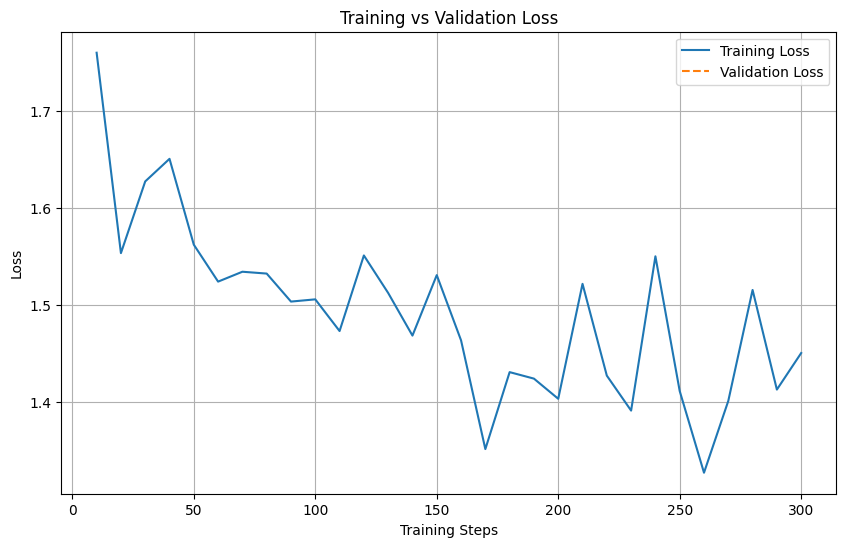

In [16]:
import matplotlib.pyplot as plt

train_loss = [log["loss"] for log in trainer.state.log_history if "loss" in log]
eval_loss = [log["eval_loss"] for log in trainer.state.log_history if "eval_loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label="Training Loss")
plt.plot(steps[:len(eval_loss)], eval_loss, label="Validation Loss", linestyle="--")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curves.png")
plt.show()

In [17]:
from unsloth import FastLanguageModel

"""
Model is not perfect at responding accurately, but i can see model has learned lot of nuances from data.
I only trained it on 300 steps on single epoch, model can be better, I am using free Google Colab. mine resources are limited
"""

# Prepare the model for Unsloth inference
finetuned_model = FastLanguageModel.for_inference(lora_layers_and_quantized_model)

# Define the input messages with explicit instruction to avoid system messages
messages = [
    {"role": "user", "content":"یک داستان در باره دانشجوی دانشگاه تهران تعریف کن."}
]

# Tokenize the input and get the attention mask
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",  # Ensure it returns PyTorch tensors
).to("cuda")

# Extract input_ids and attention_mask
input_ids = inputs  # Assuming `inputs` is a tensor
attention_mask = (input_ids != tokenizer.pad_token_id).long()  # Create attention mask if missing

# Generate output using the model
outputs = finetuned_model.generate(
    input_ids=input_ids,
    attention_mask=attention_mask,  # Pass the attention mask here
    max_new_tokens=1024,
    use_cache=True,
    temperature=1.5,
    min_p=0.1
)

# Decode the output tokens
decoded_output = tokenizer.batch_decode(outputs, skip_special_tokens=True)

# Post-process to clean unwanted system messages
clean_output = []
for response in decoded_output:
    # Explicitly remove unwanted metadata patterns
    response = response.split("user\n\n")[1] if "user\n\n" in response else response
    response = response.split("assistant\n\n")[1] if "assistant\n\n" in response else response
    clean_output.append(response)

# Print the cleaned-up output (should now only contain the joke)
print(clean_output)


['یک داستان را درباره یک دانشجوی دانشگاه تهران بنويسید.\n\nبه نام آنشان می\u200cگویند، می\u200cتوانید بگویید "مصعب" است و این کسی یک دانشجوی دانشگاه تهران است. آن شخص، پس از آن که در کلاسی که در این دانشگاه می\u200cخواهد ب Study می\u200cآید، در یک روز با یک گروهی از همکارانش در یک جلسه در کاخ پارس، صحبت می\u200cکند و می\u200cپرسد:\n\n"من در یک گروه از دوستانم در university had درclass کار می\u200cکنم و در یک جلسه در کاخ پارس داریم، پس چه کار می\u200cتوانیم انجام دهیم تا آن\u200cها را با هم closer get karim?"\n\nگروه آن\u200cها به آن-person می\u200cگویند که چه چیز\u200cها می\u200cتوانند برای نزدیک\u200cتر شدن به هم کار کنند.\n\nدر درک این جمله، یک جمله برای انجام این کار ارائه می\u200cدهند که با یک کار مرتبط باشد، مانند:\n\n"مثلا، می\u200cتوانیم از آن\u200cها را در یک نشستی درباره کارهای خود در university talk کنیم و به\u200cطور کلی بیشتر درک کنیم که چگونه کار می\u200cکنند."\n\nاین پاسخ درک کرده و گزینه\u200cهای مورد نظر را برای انجام کار برای نزدیک\u200cتر شدن به هم فراهم می\u200cآورد.

In [19]:
lora_layers_and_quantized_model.save_pretrained("lora_adapter")
